# LPD4K: YOLOv8m-OBB + ground-truth plate crops — LOCAL DATASET
**VS Code notebook | local-data version 1.2.0 | 16 September 2026**

This notebook uses the dataset that is already stored on the same machine running the VS Code/Jupyter kernel.
There is **no Google Drive, rclone, OAuth, download, or cloud-copy step** in this version.

Install the supplied `requirements.txt` and a CUDA-enabled PyTorch/torchvision build in the selected kernel environment first.

## What this notebook does
It reads your local `LPD4k.yolov8-obb` folder in place, checks all images and annotations, creates four
full-frame detector datasets, and creates four sets of **given-label-only** whole-plate crops. It trains
**`yolov8m-obb.pt`**, selects a checkpoint using the clean validation set, and evaluates that checkpoint on
clean, motion-blurred, defocus-blurred and Gaussian-blurred **validation and test** images separately.

The recognition CSV is `easyocr_finetuning_training/labels_master.csv` with exactly
`filename, words, split, plate_id`. `words` is blank on first generation; later reruns preserve your edits.

## Non-negotiable boundaries
- **No predictions are used to create recognition crops.** The crop stage runs before model training.
- **No automatic Bengali transcription or EasyOCR training occurs.** Existing OBBs locate full plates,
  not text lines. Line-level recognition needs additional region annotations later.
- The local source dataset is **read in place**. The notebook does not move or overwrite source images/labels.
- Generated blurred detector data, crops, reports and model runs are written under `WORKSPACE`.
- The original split is preserved (`valid` becomes `val`). Cross-split source-family, exact-image,
  and plate-ID conflicts stop execution. Hashes cannot establish physical vehicle/video identity;
  inspect the candidate report and dataset provenance yourself.

**Default experiment:** clean + all three blurred **training** variants, clean validation for checkpoint
selection, all four conditions evaluated separately. Set `TRAIN_ON_BLURS=False` for a clean-only baseline.
The three blur operators are reproducible synthetic approximations, not calibrated camera measurements.

**Start in `RUN_MODE="smoke"`.** It selects a few images from each split only after auditing the whole source.
Smoke outputs are isolated from `full` outputs and must not be reported as research performance.

## Dataset-safety patch in v1.2.0
- EXIF orientation is applied in memory before labels are interpreted; the source files are never rewritten.
- Unmatched/orphan label files are logged and ignored because they have no source image.
- Images containing materially out-of-range OBB coordinates are excluded from generated data and logged, rather than silently clipping/distorting the box. Tiny floating-point overshoot (<=1e-9) is clipped.
- Cross-split duplicate source groups/exact pixel duplicates are resolved without moving source files: the held-out split is kept with priority `test > val > train`; lower-priority copies are excluded and logged.


## Cell 01 - Edit the LOCAL configuration
Your dataset should already exist on disk and contain `train`, `valid`, `test`, and `data.yaml`.

For the folder layout shown in your VS Code screenshot, the expected dataset path is:
`D:\Thesis-Tahmid\LPD4K_OBB_project\LPD4k.yolov8-obb`

`WORKSPACE` must be a writable folder **outside the dataset folder**. The notebook writes all generated
blurred data, crops, reports and YOLO runs there. Start with `RUN_MODE="smoke"`.

In [ ]:
from pathlib import Path

# ---- LOCAL INPUT DATASET ----
# Change this one path only if you move/rename the dataset folder.
LOCAL_DATASET = Path(r"D:\Thesis-Tahmid\LPD4K_OBB_project\LPD4k.yolov8-obb")

# ---- GENERATED OUTPUTS / WORK AREA ----
# Keep this OUTSIDE LOCAL_DATASET.
WORKSPACE = Path(r"D:\Thesis-Tahmid\LPD4K_OBB_project\LPD4K_OBB_work")

EXPERIMENT = "lpd4k_v8m_obb_05_defocus_gaussian_stronger"        # Use a NEW name for changed data or training settings
RUN_MODE = "full"                      # First "smoke"; after checks, change to "full"
SMOKE_IMAGES_PER_SPLIT = 4
SEED = 42
PLATE_CLASS_IDS = None                  # Auto-select only when data.yaml has one class
TRAIN_ON_BLURS = False                   # True = clean + 3 blurred TRAIN variants
EPOCHS = 30                            # Full-run target; early stopping may finish sooner
IMAGE_SIZE = 640                        # Smoke uses 320 automatically
BATCH_SIZE = 8                          # Smoke uses at most 2; raise later only after a successful smoke run
DEVICE = "auto"                        # "auto", "0", or "cpu"; one GPU per notebook
ALLOW_CPU = False                       # False is correct for your RTX 4090 setup
TRAIN_ACTION = "auto"                  # "resume" only for an interrupted run with last.pt

CONFIDENCE_THRESHOLD = 0.25             # Fix before inspecting test performance
MATCH_IOU_THRESHOLD = 0.50              # Exact polygon-IoU TP threshold for custom metrics
NMS_IOU_THRESHOLD = 0.70                # Prediction suppression threshold, not TP threshold
MAX_DETECTIONS = 300
DISK_RESERVE_GB = 2.0

# Optional: manual identity knowledge, not automatic OCR. Usually leave these blank.
IDENTITY_OVERRIDES_CSV = ""             # source_image,source_group
PLATE_ID_OVERRIDES_CSV = ""             # source_image,annotation_index,plate_id
NEAR_DUPLICATE_HAMMING = 2              # Candidate review only; -1 disables this heuristic
NEAR_DUPLICATE_REPORT_LIMIT = 2000

# ---- SOURCE-CLEANING POLICY (source files are NEVER modified) ----
IGNORE_ORPHAN_LABELS = True             # Unmatched .txt files are logged, then ignored.
EXCLUDE_OUT_OF_RANGE_IMAGES = True      # Exclude the whole image if any OBB is materially outside [0,1].
CROSS_SPLIT_KEEP_PRIORITY = ("test", "val", "train")  # Protect held-out data; no source file is moved.


## Cell 02 - Load common utilities
Run once per kernel session. No dataset modification or training occurs here.
The Ultralytics API is deliberately pinned to `8.3.228`; the requested model remains YOLOv8m-OBB,
not YOLO11/YOLO26. The installed environment is recorded for reproducibility.

In [3]:
from __future__ import annotations

import csv
import hashlib
import importlib.metadata
import json
import math
import os
from pathlib import Path
import platform
import re
import shutil
import subprocess
import sys
import tempfile
import time
from dataclasses import dataclass
from datetime import datetime, timezone

import cv2
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageOps
import yaml
from tqdm.auto import tqdm

PIPELINE_VERSION = "1.2.0-local"
ULTRALYTICS_VERSION = "8.3.228"
VARIANTS = ("clean", "motion_blur", "defocus_blur", "gaussian_blur")
CROP_FOLDERS = {
    "clean": "clean_plates",
    "motion_blur": "motion_blurr_plate",
    "defocus_blur": "defocus_blurr_plate",
    "gaussian_blur": "gaussian_blurr_plate",
}
SPLITS = ("train", "val", "test")
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}
MASTER_COLUMNS = ["filename", "words", "split", "plate_id"]
cv2.setNumThreads(1)


@dataclass
class RunConfig:
    workspace: Path
    local_dataset: Path
    experiment: str = "lpd4k_v8m_obb_01"
    run_mode: str = "smoke"  # smoke is a pipeline check, NOT a research result
    smoke_images_per_split: int = 4
    seed: int = 42
    plate_class_ids: tuple[int, ...] | None = None
    train_on_blurs: bool = True
    epochs: int = 100
    imgsz: int = 640
    batch: int = 4
    device: str = "auto"  # auto, cpu, or a single CUDA index such as 0
    allow_cpu: bool = False
    disk_reserve_gb: float = 2.0
    near_duplicate_hamming: int = 2
    near_duplicate_report_limit: int = 2000
    ignore_orphan_labels: bool = True
    exclude_out_of_range_images: bool = True
    cross_split_keep_priority: tuple[str, ...] = ("test", "val", "train")
    confidence_threshold: float = 0.25
    match_iou_threshold: float = 0.50
    nms_iou_threshold: float = 0.70
    max_det: int = 300
    train_action: str = "auto"  # auto or resume
    identity_overrides_csv: str = ""
    plate_id_overrides_csv: str = ""

    def __post_init__(self):
        self.workspace = Path(self.workspace).expanduser().resolve()
        self.local_dataset = Path(self.local_dataset).expanduser().resolve()
        if self.run_mode not in {"smoke", "full"}:
            raise ValueError("run_mode must be 'smoke' or 'full'.")
        if not re.fullmatch(r"[A-Za-z0-9_-]+", self.experiment):
            raise ValueError("Use only letters, digits, underscores or hyphens in experiment.")
        if self.train_action not in {"auto", "resume"}:
            raise ValueError("train_action must be 'auto' or 'resume'.")
        if min(self.epochs, self.imgsz, self.batch, self.smoke_images_per_split) < 1:
            raise ValueError("epochs, imgsz, batch, smoke_images_per_split must be positive.")
        for v in (self.confidence_threshold, self.match_iou_threshold, self.nms_iou_threshold):
            if not 0 < v <= 1:
                raise ValueError("Confidence and IoU thresholds must be in (0, 1].")
        if self.disk_reserve_gb < 0:
            raise ValueError("disk_reserve_gb cannot be negative.")
        if set(self.cross_split_keep_priority) != {"train", "val", "test"} or len(self.cross_split_keep_priority) != 3:
            raise ValueError("cross_split_keep_priority must contain train, val and test exactly once.")

    @property
    def output(self) -> Path:
        return self.workspace / "experiments" / self.experiment / self.run_mode

    @property
    def effective_epochs(self) -> int:
        return 1 if self.run_mode == "smoke" else self.epochs

    @property
    def effective_imgsz(self) -> int:
        return 320 if self.run_mode == "smoke" else self.imgsz

    @property
    def effective_batch(self) -> int:
        return min(2, self.batch) if self.run_mode == "smoke" else self.batch


def utc_now() -> str:
    return datetime.now(timezone.utc).isoformat()


def stable_hash(value, length: int = 24) -> str:
    data = json.dumps(value, sort_keys=True, ensure_ascii=False, separators=(",", ":"))
    return hashlib.sha256(data.encode("utf-8")).hexdigest()[:length]


def hash_file(path: Path, algorithm: str = "sha256") -> str:
    digest = hashlib.new(algorithm)
    with Path(path).open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def atomic_bytes(path: Path, data: bytes) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = None
    try:
        with tempfile.NamedTemporaryFile(dir=path.parent, prefix=".tmp_", delete=False) as f:
            tmp = Path(f.name)
            f.write(data)
            f.flush()
            os.fsync(f.fileno())
        os.replace(tmp, path)
    finally:
        if tmp is not None and tmp.exists():
            tmp.unlink()


def write_json(path: Path, value) -> None:
    atomic_bytes(path, json.dumps(value, ensure_ascii=False, indent=2, allow_nan=False).encode("utf-8"))


def read_json(path: Path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def write_csv(path: Path, rows: list[dict], columns: list[str]) -> None:
    import io
    stream = io.StringIO(newline="")
    writer = csv.DictWriter(stream, fieldnames=columns, extrasaction="raise")
    writer.writeheader()
    writer.writerows(rows)
    atomic_bytes(path, stream.getvalue().encode("utf-8-sig"))


def read_csv(path: Path) -> list[dict]:
    with Path(path).open("r", encoding="utf-8-sig", newline="") as f:
        return list(csv.DictReader(f))


def read_image(path: Path) -> np.ndarray:
    """Read pixels in the same visual orientation used by the Roboflow-exported OBB labels.

    Pillow applies EXIF orientation in memory. The source file is never modified.
    """
    path = Path(path)
    try:
        with Image.open(path) as pil:
            pil = ImageOps.exif_transpose(pil).convert("RGB")
            rgb = np.asarray(pil, dtype=np.uint8).copy()
    except Exception as exc:
        raise ValueError(f"Unreadable image: {path}") from exc
    if rgb.ndim != 3 or rgb.shape[2] != 3 or rgb.size == 0:
        raise ValueError(f"Unreadable image: {path}")
    return cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)


def write_png(path: Path, image: np.ndarray) -> None:
    if image.dtype != np.uint8 or image.ndim != 3 or image.shape[2] != 3:
        raise ValueError("PNG input must be an 8-bit BGR image.")
    ok, data = cv2.imencode(".png", image, [cv2.IMWRITE_PNG_COMPRESSION, 3])
    if not ok:
        raise OSError(f"Could not encode PNG: {path}")
    atomic_bytes(path, data.tobytes())


def check_free_space(path: Path, needed_bytes: int, reserve_gb: float) -> None:
    path.mkdir(parents=True, exist_ok=True)
    free = shutil.disk_usage(path).free
    required = int(needed_bytes + reserve_gb * 1024 ** 3)
    if free < required:
        raise OSError(
            f"Insufficient disk on the KERNEL machine: {free / 1024**3:.1f} GiB free; "
            f"at least {required / 1024**3:.1f} GiB requested. "
            "Use a larger local/remote workspace; Google Drive quota is unrelated."
        )


## Cell 03 - Load the LOCAL dataset reader
This version does not download or copy the source dataset. It validates the local folder path and returns
that folder directly. The source images and labels remain where they are; generated files go to `WORKSPACE`.

In [4]:
def obtain_dataset(cfg: RunConfig) -> Path:
    """Use the existing local dataset in place; never move or overwrite source data."""
    cfg.workspace.mkdir(parents=True, exist_ok=True)
    root = Path(cfg.local_dataset).expanduser().resolve()

    if not root.is_dir():
        raise FileNotFoundError(
            f"Local dataset root not found: {root}\n"
            "Set LOCAL_DATASET in Cell 01 to the folder containing train/, valid/, test/, and data.yaml."
        )

    required = [
        root / "data.yaml",
        root / "train" / "images",
        root / "train" / "labels",
        root / "valid" / "images",
        root / "valid" / "labels",
        root / "test" / "images",
        root / "test" / "labels",
    ]
    missing = [str(p) for p in required if not p.exists()]
    if missing:
        raise FileNotFoundError(
            "The local dataset folder is incomplete. Missing required paths:\n  - "
            + "\n  - ".join(missing)
        )

    output = cfg.output.resolve()
    if output == root or output.is_relative_to(root):
        raise ValueError(
            "WORKSPACE/experiment output must be outside LOCAL_DATASET so generated files never mix with source data."
        )

    print("Using LOCAL dataset in place:", root)
    print("No Google Drive/rclone step is used.")
    print("Generated outputs will be written under:", cfg.workspace)
    return root

## Cell 04 - Load dataset checks and split-identity logic
Checks include label format, class IDs, coordinate ranges, convex/cyclic corners, degenerate boxes,
missing labels, orphan labels, duplicate annotations, EXIF orientation, and split leakage.
An intentionally negative image must have an explicit empty label file.

`plate_id` is derived from the Roboflow-source filename family plus annotation index, unless overridden.
It is stable across the four generated variants and independent of split. It is **not** a recognized
registration number. Different photographs of the same physical plate require identity metadata/manual
grouping; object ordering may also differ across independent multi-object exports.

In [5]:
def load_class_names(root: Path) -> dict[int, str]:
    metadata_path = root / "data.yaml"
    if not metadata_path.exists():
        raise FileNotFoundError(f"Expected {metadata_path}; select the dataset root, not images/labels/valid.")
    # Only metadata is used. Untrusted YAML 'download' entries are never executed.
    data = yaml.safe_load(metadata_path.read_text(encoding="utf-8-sig"))
    if not isinstance(data, dict):
        raise ValueError("data.yaml must contain a mapping.")
    names = data.get("names")
    if isinstance(names, list):
        names = dict(enumerate(str(x) for x in names))
    elif isinstance(names, dict):
        names = {int(k): str(v) for k, v in names.items()}
    else:
        raise ValueError("data.yaml must supply names as a list or an integer-keyed mapping.")
    if not names or sorted(names) != list(range(len(names))):
        raise ValueError("Class IDs must be contiguous, starting at zero.")
    if "nc" in data and int(data["nc"]) != len(names):
        raise ValueError("The nc value in data.yaml does not match names.")
    return names


class OutOfBoundsOBBError(ValueError):
    pass


def parse_obb_text(text: str, width: int, height: int, nc: int) -> list[dict]:
    """Strict OBB parser. Tiny floating noise is tolerated; material out-of-frame OBBs are not distorted."""
    annotations = []
    seen = set()
    eps = 1e-9
    for line_number, line in enumerate(text.splitlines(), start=1):
        if not line.strip():
            continue
        parts = line.split()
        if len(parts) != 9:
            raise ValueError(f"Line {line_number}: expected 9 values (class + 8 OBB coordinates), got {len(parts)}.")
        try:
            values = np.asarray([float(x) for x in parts], dtype=np.float64)
        except ValueError as exc:
            raise ValueError(f"Line {line_number}: non-numeric token.") from exc
        if not np.isfinite(values).all():
            raise ValueError(f"Line {line_number}: NaN or infinity.")
        class_id = int(values[0])
        if values[0] != class_id or not 0 <= class_id < nc:
            raise ValueError(f"Line {line_number}: invalid class ID {values[0]}.")
        normalized = values[1:].reshape(4, 2)
        lo, hi = float(normalized.min()), float(normalized.max())
        if lo < -eps or hi > 1.0 + eps:
            raise OutOfBoundsOBBError(
                f"Line {line_number}: OBB coordinates materially outside [0,1] "
                f"(min={lo:.12g}, max={hi:.12g}); image excluded instead of clipping/distorting ground truth."
            )
        normalized = np.clip(normalized, 0.0, 1.0)
        points = (normalized * [width, height]).astype(np.float32)
        if len(np.unique(points, axis=0)) != 4 or not cv2.isContourConvex(points):
            raise ValueError(f"Line {line_number}: corners must form a non-self-intersecting convex quadrilateral in cyclic order.")
        area = abs(float(cv2.contourArea(points)))
        edges = np.roll(points, -1, axis=0) - points
        lengths = np.linalg.norm(edges, axis=1)
        if area < 4.0 or lengths.min() < 2.0:
            raise ValueError(f"Line {line_number}: degenerate or sub-2-pixel box; review this annotation.")
        duplicate_key = (class_id, tuple(sorted(tuple(p) for p in np.round(normalized, 10))))
        if duplicate_key in seen:
            raise ValueError(f"Line {line_number}: duplicate annotation in the same image.")
        seen.add(duplicate_key)
        cosines = np.abs(np.sum(edges * np.roll(edges, -1, axis=0), axis=1) /
                         (lengths * np.roll(lengths, -1)))
        annotations.append({"annotation_index": len(annotations) + 1, "source_line": line_number,
                            "class_id": class_id, "normalized": normalized.tolist(),
                            "area_pixels": area, "rectangle_error": float(cosines.max())})
    return annotations

def source_family(stem: str) -> str:
    # Roboflow's export suffix is not a physical vehicle identity.
    return stem.split(".rf.", 1)[0].casefold()


def difference_hash(image: np.ndarray) -> int:
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    tiny = cv2.resize(gray, (9, 8), interpolation=cv2.INTER_AREA)
    bits = (tiny[:, 1:] > tiny[:, :-1]).ravel()
    answer = 0
    for bit in bits:
        answer = (answer << 1) | int(bit)
    return answer


def read_overrides(path: str, required: set[str]) -> list[dict]:
    if not path:
        return []
    rows = read_csv(Path(path).expanduser())
    with Path(path).expanduser().open(encoding="utf-8-sig", newline="") as f:
        fields = set(csv.DictReader(f).fieldnames or [])
    if not required.issubset(fields):
        raise ValueError(f"Override CSV requires columns {sorted(required)}: {path}")
    return rows


def audit_dataset(root: Path, cfg: RunConfig) -> tuple[list[dict], dict[int, str], list[int], dict]:
    report_dir = cfg.output / "reports"
    report_dir.mkdir(parents=True, exist_ok=True)
    names = load_class_names(root)
    plate_classes = list(cfg.plate_class_ids) if cfg.plate_class_ids is not None else None
    if plate_classes is None:
        if len(names) != 1:
            raise ValueError(f"This dataset has multiple classes {names}. Set PLATE_CLASS_IDS explicitly for recognition crops.")
        plate_classes = [0]
    if not plate_classes or any(i not in names for i in plate_classes):
        raise ValueError("PLATE_CLASS_IDS must refer to real classes in data.yaml.")

    identity_rows = read_overrides(cfg.identity_overrides_csv, {"source_image", "source_group"})
    identity = {}
    for row in identity_rows:
        key = row["source_image"].replace("\\", "/")
        if key in identity or not row["source_group"].strip():
            raise ValueError("Duplicate/blank identity override.")
        identity[key] = row["source_group"].strip()
    plate_rows = read_overrides(cfg.plate_id_overrides_csv, {"source_image", "annotation_index", "plate_id"})
    plate_overrides = {}
    for row in plate_rows:
        key = (row["source_image"].replace("\\", "/"), int(row["annotation_index"]))
        if key in plate_overrides or not row["plate_id"].strip():
            raise ValueError("Duplicate/blank plate ID override.")
        plate_overrides[key] = row["plate_id"].strip()

    issues, records = [], []
    orphan_rows, exif_rows, excluded_rows = [], [], []
    scanned_images = 0

    def issue(severity, category, source, detail):
        issues.append({"severity": severity, "category": category,
                       "source_image": source, "detail": detail})

    split_folders = {}
    for split in SPLITS:
        options = [root / split] if split != "val" else [root / "valid", root / "val"]
        found = [p for p in options if p.is_dir()]
        if len(found) != 1:
            raise ValueError(f"Expected exactly one folder for {split}: {[str(x) for x in options]}")
        split_folders[split] = found[0]
        images_dir, labels_dir = found[0] / "images", found[0] / "labels"
        if not images_dir.is_dir() or not labels_dir.is_dir():
            raise FileNotFoundError(f"{found[0]} must contain both images/ and labels/.")
        files = sorted(p for p in images_dir.rglob("*") if p.suffix.lower() in IMAGE_EXTENSIONS)
        if not files:
            raise ValueError(f"No supported images in {images_dir}.")
        expected_labels = set()
        duplicate_names = set()
        for path in tqdm(files, desc=f"Audit all {split} images"):
            scanned_images += 1
            source = path.relative_to(root).as_posix()
            relative = path.relative_to(images_dir)
            label = labels_dir / relative.with_suffix(".txt")
            label_key = label.relative_to(labels_dir).as_posix().casefold()
            expected_labels.add(label_key)
            if label_key in duplicate_names:
                issue("error", "ambiguous_label_pair", source, "Two images map to the same label filename.")
                continue
            duplicate_names.add(label_key)
            try:
                with Image.open(path) as pil:
                    orientation = int(pil.getexif().get(274, 1))
                if orientation != 1:
                    exif_rows.append({"source_image": source, "split": split, "exif_orientation": orientation})
                image = read_image(path)  # EXIF-transposed in memory; source file remains untouched
                height, width = image.shape[:2]
                if not label.exists():
                    raise ValueError("Missing label file. An intentional negative needs an explicit empty .txt file.")
                text = label.read_text(encoding="utf-8-sig")
                try:
                    annotations = parse_obb_text(text, width, height, len(names))
                except OutOfBoundsOBBError as exc:
                    if cfg.exclude_out_of_range_images:
                        excluded_rows.append({"source_image": source, "split": split,
                                              "reason": "out_of_range_obb", "detail": str(exc)})
                        continue
                    raise
                group = identity.get(source, source_family(path.stem))
                for ann in annotations:
                    ann["plate_id"] = plate_overrides.get(
                        (source, ann["annotation_index"]),
                        "plate_" + stable_hash([group, ann["annotation_index"]], 24))
                    if ann["rectangle_error"] > 0.05:
                        issue("warning", "nonrectangular_quad", source,
                              f"Annotation {ann['annotation_index']} is not a near rectangle. "
                              "GT crop retains its quadrilateral; YOLO internally uses a rotated rectangle.")
                digest = hashlib.sha256()
                digest.update(str(image.shape).encode("ascii"))
                digest.update(image.tobytes())
                records.append({"source_image": source, "image_path": str(path),
                                "label_path": str(label), "split": split, "width": width, "height": height,
                                "source_group": group, "pixel_sha256": digest.hexdigest(),
                                "label_sha256": hash_file(label),
                                "dhash": difference_hash(image),
                                "image_id": "img_" + stable_hash(source, 20), "annotations": annotations})
            except Exception as exc:
                issue("error", "invalid_image_or_label", source, str(exc))
        for label in labels_dir.rglob("*"):
            if label.is_file() and label.suffix.lower() == ".txt":
                key = label.relative_to(labels_dir).as_posix().casefold()
                if key not in expected_labels:
                    orphan_rows.append({"split": split, "label": label.relative_to(root).as_posix()})

    if orphan_rows:
        if cfg.ignore_orphan_labels:
            issue("warning", "orphan_labels_ignored", "",
                  f"{len(orphan_rows)} label files have no matching image and were ignored; see ignored_orphan_labels.csv.")
        else:
            issue("error", "orphan_labels_present", "",
                  f"{len(orphan_rows)} label files have no matching image; see ignored_orphan_labels.csv.")
    if exif_rows:
        issue("warning", "exif_orientation_applied", "",
              f"Applied EXIF orientation in memory to {len(exif_rows)} images; source files were not rewritten. See exif_orientation_applied.csv.")
    if excluded_rows:
        issue("warning", "out_of_range_images_excluded", "",
              f"Excluded {len(excluded_rows)} source images containing materially out-of-range OBB coordinates; see excluded_source_images.csv.")

    # Validate overrides against every otherwise-usable source before cross-split de-duplication.
    prefilter_records = list(records)
    source_set = {r["source_image"] for r in prefilter_records}
    for key in identity:
        if key not in source_set:
            issue("error", "unused_identity_override", key, "No matching usable image.")
    real_plates = {(r["source_image"], a["annotation_index"]) for r in prefilter_records for a in r["annotations"]}
    for key in plate_overrides:
        if key not in real_plates:
            issue("error", "unused_plate_override", key[0], str(key[1]))

    # Resolve exact/source-family cross-split leakage conservatively without changing source files or reassigning splits.
    priority = {name: len(cfg.cross_split_keep_priority) - idx
                for idx, name in enumerate(cfg.cross_split_keep_priority)}
    leakage_rows, cross_exclusion_rows = [], []
    excluded_sources = set()
    for field in ("source_group", "pixel_sha256"):
        groups = {}
        for record in records:
            groups.setdefault(record[field], []).append(record)
        for group, items in groups.items():
            splits = {r["split"] for r in items}
            if len(splits) <= 1:
                continue
            keep_split = max(splits, key=lambda x: priority[x])
            for r in items:
                leakage_rows.append({"check": field, "group_id": group, "split": r["split"],
                                     "source_image": r["source_image"]})
                if r["split"] != keep_split:
                    excluded_sources.add(r["source_image"])
                    cross_exclusion_rows.append({"check": field, "group_id": group,
                                                 "kept_split": keep_split, "excluded_split": r["split"],
                                                 "source_image": r["source_image"]})
    if excluded_sources:
        records = [r for r in records if r["source_image"] not in excluded_sources]
        for row in cross_exclusion_rows:
            excluded_rows.append({"source_image": row["source_image"], "split": row["excluded_split"],
                                  "reason": "cross_split_duplicate",
                                  "detail": f"{row['check']}={row['group_id']}; kept {row['kept_split']} by priority {cfg.cross_split_keep_priority}"})
        issue("warning", "cross_split_duplicates_excluded", "",
              f"Excluded {len(excluded_sources)} lower-priority cross-split duplicate source images; "
              f"priority is {cfg.cross_split_keep_priority}. See cross_split_exclusions.csv.")

    # After source-family/exact-pixel cleanup, enforce plate_id disjointness too.
    by_plate = {}
    for r in records:
        for a in r["annotations"]:
            if a["class_id"] in plate_classes:
                by_plate.setdefault(a["plate_id"], []).append(r)
    plate_excluded = set()
    for plate_id, items in by_plate.items():
        splits = {r["split"] for r in items}
        if len(splits) <= 1:
            continue
        keep_split = max(splits, key=lambda x: priority[x])
        for r in items:
            leakage_rows.append({"check": "plate_id", "group_id": plate_id, "split": r["split"],
                                 "source_image": r["source_image"]})
            if r["split"] != keep_split:
                plate_excluded.add(r["source_image"])
                cross_exclusion_rows.append({"check": "plate_id", "group_id": plate_id,
                                             "kept_split": keep_split, "excluded_split": r["split"],
                                             "source_image": r["source_image"]})
    if plate_excluded:
        records = [r for r in records if r["source_image"] not in plate_excluded]
        for source in sorted(plate_excluded):
            rec = next(r for r in prefilter_records if r["source_image"] == source)
            excluded_rows.append({"source_image": source, "split": rec["split"],
                                  "reason": "cross_split_plate_id",
                                  "detail": "Lower-priority copy excluded to keep plate_id in one inherited split."})
        issue("warning", "cross_split_plate_ids_excluded", "",
              f"Excluded {len(plate_excluded)} additional lower-priority images to keep each plate_id in one split.")

    for split in SPLITS:
        items = [r for r in records if r["split"] == split]
        if not any(a["class_id"] in plate_classes for r in items for a in r["annotations"]):
            issue("error", "no_plate_ground_truth", split, "Each split must contain at least one labeled plate after exclusions.")
    if len({r["image_id"] for r in records}) != len(records):
        issue("error", "image_id_collision", "", "Generated image IDs are not unique.")

    near_rows = []
    if cfg.near_duplicate_hamming >= 0:
        for i, first_split in enumerate(SPLITS):
            for second_split in SPLITS[i+1:]:
                first = [r for r in records if r["split"] == first_split]
                second = [r for r in records if r["split"] == second_split]
                for a in first:
                    for b in second:
                        if a["pixel_sha256"] == b["pixel_sha256"]:
                            continue
                        distance = (a["dhash"] ^ b["dhash"]).bit_count()
                        if distance <= cfg.near_duplicate_hamming:
                            near_rows.append({"source_image_a": a["source_image"], "split_a": a["split"],
                                              "source_image_b": b["source_image"], "split_b": b["split"],
                                              "dhash_distance": distance})
                        if len(near_rows) >= cfg.near_duplicate_report_limit:
                            break
                    if len(near_rows) >= cfg.near_duplicate_report_limit:
                        break
                if len(near_rows) >= cfg.near_duplicate_report_limit:
                    break
            if len(near_rows) >= cfg.near_duplicate_report_limit:
                break

    write_csv(report_dir / "dataset_issues.csv", issues, ["severity", "category", "source_image", "detail"])
    write_csv(report_dir / "ignored_orphan_labels.csv", orphan_rows, ["split", "label"])
    write_csv(report_dir / "exif_orientation_applied.csv", exif_rows, ["source_image", "split", "exif_orientation"])
    write_csv(report_dir / "excluded_source_images.csv", excluded_rows, ["source_image", "split", "reason", "detail"])
    write_csv(report_dir / "cross_split_leakage.csv", leakage_rows, ["check", "group_id", "split", "source_image"])
    write_csv(report_dir / "cross_split_exclusions.csv", cross_exclusion_rows,
              ["check", "group_id", "kept_split", "excluded_split", "source_image"])
    write_csv(report_dir / "near_duplicate_candidates.csv", near_rows,
              ["source_image_a", "split_a", "source_image_b", "split_b", "dhash_distance"])
    inventory = [{k: r[k] for k in ("source_image", "split", "source_group", "image_id", "width", "height", "pixel_sha256")}
                 | {"annotations": len(r["annotations"])} for r in records]
    write_csv(report_dir / "source_inventory.csv", inventory,
              ["source_image", "split", "source_group", "image_id", "width", "height", "pixel_sha256", "annotations"])
    write_csv(report_dir / "identity_overrides_TEMPLATE.csv", [], ["source_image", "source_group"])
    write_csv(report_dir / "plate_id_overrides_TEMPLATE.csv", [], ["source_image", "annotation_index", "plate_id"])
    write_json(report_dir / "source_annotations.json", records)
    summary = {"audit_utc": utc_now(), "scanned_images": scanned_images, "images": len(records), "classes": names,
               "plate_class_ids": plate_classes, "errors": sum(i["severity"] == "error" for i in issues),
               "warnings": sum(i["severity"] == "warning" for i in issues),
               "orphan_labels_ignored": len(orphan_rows), "exif_images_normalized": len(exif_rows),
               "excluded_source_images": len({r['source_image'] for r in excluded_rows}),
               "cross_split_candidates": len(leakage_rows),
               "near_duplicate_candidates": len(near_rows),
               "near_duplicate_report_capped": len(near_rows) >= cfg.near_duplicate_report_limit,
               "source_fingerprint": stable_hash([[r["source_image"], r["pixel_sha256"], r["label_sha256"],
                                                     r["source_group"], [a["plate_id"] for a in r["annotations"]]]
                                                    for r in records], 64),
               "limits": "EXIF is normalized in memory. Orphan labels are ignored. Materially out-of-range OBB images and lower-priority cross-split duplicates are excluded and logged; source files are never modified."}
    write_json(report_dir / "audit_summary.json", summary)
    print(json.dumps(summary, ensure_ascii=False, indent=2))
    if summary["errors"]:
        raise ValueError(f"Audit stopped with {summary['errors']} fatal error(s). Read {report_dir / 'dataset_issues.csv'}. "
                         "No fatal error was silently dropped.")
    return records, names, plate_classes, summary

def select_records(records: list[dict], cfg: RunConfig, plate_classes: list[int]) -> list[dict]:
    if cfg.run_mode == "full":
        return records
    selected = []
    for split in SPLITS:
        items = sorted([r for r in records if r["split"] == split],
                       key=lambda r: stable_hash([cfg.seed, r["source_image"]]))
        positives = [r for r in items if any(a["class_id"] in plate_classes for a in r["annotations"])]
        chosen = items[:cfg.smoke_images_per_split]
        if positives and not any(r in positives for r in chosen):
            chosen[-1] = positives[0]
        selected.extend(chosen)
    print(f"SMOKE MODE: selecting {len(selected)} source images after auditing the ENTIRE source dataset.")
    return selected


## Cell 05 - Load full-frame blur and ground-truth crop generation
Motion blur uses an angled line kernel, defocus uses a disk kernel, and Gaussian blur approximates
small isotropic optical/processing softness. Parameters are seeded per source image and logged.
All blur is applied to the **full original-sized frame before cropping**. Every annotated plate gets
four crops, including multiple plates in one image. No detector results enter these functions.

The four supplied corners drive a perspective warp at approximately native region size. The code does
not force square motorcycle plates into landscape, does not invent tight plate corners, and cannot infer
reading orientation from a box. Inspect the crop previews; loose or inaccurate given boxes remain loose.
`clean` means the provided image, which may already contain blur/compression/Roboflow augmentation.

In [6]:
def order_quad(points: np.ndarray) -> np.ndarray:
    q = np.asarray(points, dtype=np.float32).reshape(4, 2)
    center = q.mean(axis=0)
    cycle = q[np.argsort(np.arctan2(q[:, 1] - center[1], q[:, 0] - center[0]))]
    # Cyclic order, starting at the top-left-like corner. No forced landscape rotation.
    start = int(np.argmin(cycle[:, 0] + cycle[:, 1]))
    ordered = np.roll(cycle, -start, axis=0)
    if not cv2.isContourConvex(ordered):
        raise ValueError("Cannot order a degenerate ground-truth quadrilateral.")
    return ordered


def rectify_gt_plate(image: np.ndarray, normalized_points) -> np.ndarray:
    """No model, prediction, confidence, detection result or OCR is used here."""
    height, width = image.shape[:2]
    q = order_quad(np.asarray(normalized_points, dtype=np.float32) * [width, height])
    w = max(np.linalg.norm(q[1] - q[0]), np.linalg.norm(q[2] - q[3]))
    h = max(np.linalg.norm(q[3] - q[0]), np.linalg.norm(q[2] - q[1]))
    out_w, out_h = max(2, int(round(w))), max(2, int(round(h)))
    target = np.asarray([[0, 0], [out_w - 1, 0], [out_w - 1, out_h - 1], [0, out_h - 1]], dtype=np.float32)
    transform = cv2.getPerspectiveTransform(q.astype(np.float32), target)
    crop = cv2.warpPerspective(image, transform, (out_w, out_h), flags=cv2.INTER_LINEAR,
                               borderMode=cv2.BORDER_REPLICATE)
    if crop.size == 0:
        raise ValueError("Empty ground-truth crop.")
    return crop


def blur_parameters(record: dict, seed: int, plate_classes: list[int]) -> dict:
    rng = np.random.default_rng(
        int(stable_hash([seed, record["source_image"], "blur_v4"], 16), 16)
    )

    short_sides = []

    for annotation in record["annotations"]:
        if annotation["class_id"] in plate_classes:
            q = np.asarray(annotation["normalized"]) * [
                record["width"],
                record["height"]
            ]
            short_sides.append(
                float(
                    np.min(
                        np.linalg.norm(
                            np.roll(q, -1, axis=0) - q,
                            axis=1
                        )
                    )
                )
            )

    scale = (
        float(np.median(short_sides))
        if short_sides
        else min(record["width"], record["height"]) * 0.08
    )

    # KEEP motion blur exactly as before
    length = int(
        np.clip(
            round(scale * rng.uniform(0.11, 0.24)),
            7,
            43
        )
    )

    if length % 2 == 0:
        length = min(length + 1, 43)

    return {
        "motion_length_px": length,
        "motion_angle_deg": float(rng.uniform(0, 180)),

        # INCREASE defocus blur only
        "defocus_radius_px": int(
            np.clip(
                round(scale * rng.uniform(0.040, 0.085)),
                4,
                17
            )
        ),

        # INCREASE gaussian blur only
        "gaussian_sigma_px": float(
            np.clip(
                scale * rng.uniform(0.030, 0.070),
                1.8,
                8.0
            )
        )
    }


def motion_kernel(length: int, angle_degrees: float) -> np.ndarray:
    kernel = np.zeros((length, length), dtype=np.float32)
    center = (length - 1) / 2
    radius = (length - 1) / 2
    theta = np.deg2rad(angle_degrees)
    # Dense subpixel line rasterized bilinearly: smoother than rounded endpoint kernels.
    for t in np.linspace(-radius, radius, max(32, length * 8)):
        x, y = center + t * np.cos(theta), center + t * np.sin(theta)
        x0, y0 = math.floor(x), math.floor(y)
        for xx, wx in ((x0, 1 - (x - x0)), (x0 + 1, x - x0)):
            for yy, wy in ((y0, 1 - (y - y0)), (y0 + 1, y - y0)):
                if 0 <= xx < length and 0 <= yy < length:
                    kernel[yy, xx] += wx * wy
    return kernel / kernel.sum()


def apply_variant(image: np.ndarray, variant: str, params: dict) -> np.ndarray:
    if variant == "clean":
        return image
    if variant == "motion_blur":
        kernel = motion_kernel(params["motion_length_px"], params["motion_angle_deg"])
        return cv2.filter2D(image, -1, kernel, borderType=cv2.BORDER_REFLECT_101)
    if variant == "defocus_blur":
        radius = params["defocus_radius_px"]
        yy, xx = np.mgrid[-radius:radius + 1, -radius:radius + 1]
        kernel = ((xx * xx + yy * yy) <= radius * radius).astype(np.float32)
        kernel /= kernel.sum()
        return cv2.filter2D(image, -1, kernel, borderType=cv2.BORDER_REFLECT_101)
    if variant == "gaussian_blur":
        sigma = params["gaussian_sigma_px"]
        return cv2.GaussianBlur(image, (0, 0), sigmaX=sigma, sigmaY=sigma,
                               borderType=cv2.BORDER_REFLECT_101)
    raise ValueError(f"Unknown blur variant: {variant}")


def preserve_master(path: Path, rows: list[dict]) -> None:
    """Generate blanks on first run; preserve exact manual words on later runs."""
    if len({r["filename"] for r in rows}) != len(rows):
        raise ValueError("Duplicate recognition filenames would make the master CSV ambiguous.")
    if path.exists():
        with path.open(encoding="utf-8-sig", newline="") as f:
            reader = csv.DictReader(f)
            if reader.fieldnames != MASTER_COLUMNS:
                raise ValueError(f"Do not rename/reorder master CSV columns: expected {MASTER_COLUMNS}")
            old_rows = list(reader)
        if len({r["filename"] for r in old_rows}) != len(old_rows):
            raise ValueError("The edited labels_master.csv contains duplicate filenames.")
        old = {r["filename"]: r for r in old_rows}
        new_names = {r["filename"] for r in rows}
        if set(old) - new_names:
            raise ValueError("Old master rows would disappear. Use a new experiment instead of overwriting manual work.")
        for row in rows:
            previous = old.get(row["filename"])
            if previous:
                if (previous["split"], previous["plate_id"]) != (row["split"], row["plate_id"]):
                    raise ValueError("A crop identity or split changed. Use a new experiment.")
                row["words"] = previous["words"]
        backup = path.with_name(path.name + ".bak_" + datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%f"))
        shutil.copy2(path, backup)
    write_csv(path, rows, MASTER_COLUMNS)


def estimate_generation_bytes(records: list[dict]) -> int:
    # Conservative uncompressed bound: four full PNG frames plus four crops per plate,
    # with extra room for encoders/metadata. It is a disk guard, not a quota promise.
    full_pixels = sum(r["width"] * r["height"] for r in records)
    crop_pixels = sum(max(a["area_pixels"], 4) * 1.5 for r in records for a in r["annotations"])
    return int((full_pixels + crop_pixels) * 3 * 4 * 1.1)


def prepare_artifacts(records: list[dict], names: dict[int, str], plate_classes: list[int],
                      audit: dict, cfg: RunConfig) -> dict:
    root = cfg.output
    root.mkdir(parents=True, exist_ok=True)
    spec = {"pipeline_version": PIPELINE_VERSION, "source_fingerprint": audit["source_fingerprint"],
            "selected_images": [r["source_image"] for r in records], "seed": cfg.seed,
            "plate_class_ids": plate_classes, "variants": list(VARIANTS),
            "crop": "given four corners; perspective warp; native size; no padding",
            "blur_policy": "motion line / disk defocus / Gaussian v1; full-frame before crop"}
    spec["fingerprint"] = stable_hash(spec, 64)
    marker = root / "generation_spec.json"
    if marker.exists() and read_json(marker) != spec:
        raise ValueError("Data/blur/crop configuration changed. Select a NEW EXPERIMENT name; old crops/transcriptions are protected.")
    if not marker.exists():
        check_free_space(root, estimate_generation_bytes(records), cfg.disk_reserve_gb)
        write_json(marker, spec)
    else:
        print("Reusing unchanged generation settings; missing output files will be regenerated.")

    for folder in CROP_FOLDERS.values():
        for split in SPLITS:
            (root / folder / split).mkdir(parents=True, exist_ok=True)
    for variant in VARIANTS:
        for split in SPLITS:
            for kind in ("images", "labels"):
                (root / "detector_data" / variant / split / kind).mkdir(parents=True, exist_ok=True)
    master, crop_rows, detector_rows = [], [], []
    expected_plate_count = 0
    for index, record in enumerate(tqdm(records, desc="Generate full-frame variants and GT-only crops")):
        if index % 100 == 0:
            check_free_space(root, 0, cfg.disk_reserve_gb)
        image = read_image(Path(record["image_path"]))
        params = blur_parameters(record, cfg.seed, plate_classes)
        labels = []
        for ann in record["annotations"]:
            flat = np.asarray(ann["normalized"]).ravel()
            labels.append(str(ann["class_id"]) + " " + " ".join(f"{v:.12g}" for v in flat))
        label_text = "\n".join(labels) + ("\n" if labels else "")
        selected_annotations = [a for a in record["annotations"] if a["class_id"] in plate_classes]
        expected_plate_count += len(selected_annotations)
        for variant in VARIANTS:
            varied = apply_variant(image, variant, params)  # blur whole scene BEFORE crop
            image_path = root / "detector_data" / variant / record["split"] / "images" / (record["image_id"] + ".png")
            label_path = image_path.parent.parent / "labels" / image_path.with_suffix(".txt").name
            if not image_path.exists():
                write_png(image_path, varied)
            atomic_bytes(label_path, label_text.encode("utf-8"))
            detector_rows.append({"variant": variant, "split": record["split"],
                                  "image_id": record["image_id"], "source_image": record["source_image"],
                                  "image": image_path.relative_to(root).as_posix(),
                                  "label": label_path.relative_to(root).as_posix(),
                                  "blur_parameters": json.dumps(params, sort_keys=True) if variant != "clean" else "{}"})
            for ann in selected_annotations:
                filename = f"{record['image_id']}__p{ann['annotation_index']:03d}.png"
                relative = Path(CROP_FOLDERS[variant]) / record["split"] / filename
                crop = rectify_gt_plate(varied, ann["normalized"])  # THE ONLY crop function call
                if not (root / relative).exists():
                    write_png(root / relative, crop)
                master.append({"filename": relative.as_posix(), "words": "", "split": record["split"],
                               "plate_id": ann["plate_id"]})
                crop_rows.append({"filename": relative.as_posix(), "variant": variant,
                                  "split": record["split"], "plate_id": ann["plate_id"],
                                  "source_image": record["source_image"], "image_id": record["image_id"],
                                  "annotation_index": ann["annotation_index"], "class_id": ann["class_id"],
                                  "crop_width": crop.shape[1], "crop_height": crop.shape[0],
                                  "given_corners_normalized": json.dumps(ann["normalized"]),
                                  "blur_parameters": json.dumps(params, sort_keys=True) if variant != "clean" else "{}"})
    if len(master) != 4 * expected_plate_count:
        raise AssertionError("Expected exactly four crops per selected ground-truth plate annotation.")
    master.sort(key=lambda r: (r["split"], r["plate_id"], r["filename"]))
    by_plate = {}
    for row in master:
        by_plate.setdefault(row["plate_id"], set()).add(row["split"])
    if any(len(v) != 1 for v in by_plate.values()):
        raise AssertionError("Recognition split leakage: one plate_id has multiple splits.")
    for row in master:
        if not (root / row["filename"]).is_file():
            raise FileNotFoundError(row["filename"])
    for row in detector_rows:
        if not (root / row["image"]).is_file() or not (root / row["label"]).is_file():
            raise FileNotFoundError("Incomplete detector dataset output.")

    ocr_dir = root / "easyocr_finetuning_training"
    preserve_master(ocr_dir / "labels_master.csv", master)
    write_csv(root / "reports" / "crop_manifest.csv", crop_rows,
              ["filename", "variant", "split", "plate_id", "source_image", "image_id", "annotation_index",
               "class_id", "crop_width", "crop_height", "given_corners_normalized", "blur_parameters"])
    write_csv(root / "reports" / "detector_manifest.csv", detector_rows,
              ["variant", "split", "image_id", "source_image", "image", "label", "blur_parameters"])
    info = ("labels_master.csv is UTF-8 with BOM. Columns: filename,words,split,plate_id.\n"
            "Resolve filename relative to the PARENT of this easyocr_finetuning_training folder.\n"
            "words is blank on first generation. Fill only this column with the exact visible Bengali text.\n"
            "These are WHOLE-PLATE crops from provided OBB annotations, not detected text-line crops.\n"
            "For a line recognizer, create true text-line regions separately before recognition training.\n"
            "No OCR recognition model is trained by this notebook. Never invent unreadable text.\n"
            "All four variants inherit the source split and plate_id. Do not resplit individual CSV rows.\n"
            "plate_id is a source-annotation identity, not a guarantee that two different photos show different physical plates.\n"
            "Review identity/near-duplicate reports and use optional grouping overrides where known.\n"
            "Rerunning unchanged preparation preserves words and backs up the old CSV. Close it in Excel first.\n")
    atomic_bytes(ocr_dir / "README.txt", info.encode("utf-8"))
    summary = {"run_mode": cfg.run_mode, "source_images_selected": len(records),
               "source_plate_annotations": expected_plate_count, "recognition_images": len(master),
               "master_csv": str(ocr_dir / "labels_master.csv"), "generation_fingerprint": spec["fingerprint"]}
    write_json(root / "generation_complete.json", summary)
    return summary


def make_dataset_yamls(names: dict[int, str], cfg: RunConfig) -> dict[str, Path]:
    root = cfg.output
    config_dir = root / "dataset_configs"
    config_dir.mkdir(parents=True, exist_ok=True)
    training_variants = VARIANTS if cfg.train_on_blurs else ("clean",)
    train_dirs = [(root / "detector_data" / v / "train" / "images").resolve().as_posix() for v in training_variants]
    paths = {}
    for key in ("training",) + VARIANTS:
        variant = "clean" if key == "training" else key
        data = {"path": root.resolve().as_posix(), "train": train_dirs,
                "val": (root / "detector_data" / variant / "val" / "images").resolve().as_posix(),
                "test": (root / "detector_data" / variant / "test" / "images").resolve().as_posix(),
                "nc": len(names), "names": names}
        output = config_dir / (key + ".yaml")
        atomic_bytes(output, yaml.safe_dump(data, allow_unicode=True, sort_keys=False).encode("utf-8"))
        paths[key] = output
    return paths


def create_crop_previews(cfg: RunConfig, max_plates: int = 6) -> list[Path]:
    manifest = read_csv(cfg.output / "reports" / "crop_manifest.csv")
    observations = []
    seen = set()
    for row in manifest:
        key = (row["image_id"], row["annotation_index"])
        if key not in seen:
            seen.add(key)
            observations.append(key)
    results = []
    for number, key in enumerate(observations[:max_plates], start=1):
        rows = [r for r in manifest if (r["image_id"], r["annotation_index"]) == key]
        lookup = {r["variant"]: r for r in rows}
        panel = Image.new("RGB", (1040, 330), "white")
        draw = ImageDraw.Draw(panel)
        draw.text((12, 8), f"Given-label crops only | {key[0]} | annotation {key[1]}", fill="black")
        for i, variant in enumerate(VARIANTS):
            crop = Image.open(cfg.output / lookup[variant]["filename"]).convert("RGB")
            crop.thumbnail((245, 270), Image.Resampling.LANCZOS)
            x = i * 260 + (260 - crop.width) // 2
            panel.paste(crop, (x, 48))
            draw.text((i * 260 + 12, 30), variant, fill="black")
        path = cfg.output / "quality_checks" / f"gt_crop_preview_{number:02d}.jpg"
        path.parent.mkdir(parents=True, exist_ok=True)
        panel.save(path, quality=95)
        results.append(path)
    return results

## Cell 06 - Load environment checks and detector training
The model is `yolov8m-obb.pt`. Training uses full scenes, never the recognition crops. `workers=0`
avoids notebook/Windows multiprocessing pitfalls. Mirroring and mosaic are disabled so text is not
flipped by these augmentations. There are still modest train-only geometric/color augmentations.
The code protects existing runs, saves `best.pt` and `last.pt`, and supports interrupted-run resumption.

In [ ]:
def check_environment(cfg: RunConfig, *, require_ultralytics: bool = True) -> dict:
    import torch
    if require_ultralytics:
        try:
            actual = importlib.metadata.version("ultralytics")
        except importlib.metadata.PackageNotFoundError as exc:
            raise RuntimeError("Install requirements.txt in the SELECTED kernel environment, then restart the kernel.") from exc
        if actual != ULTRALYTICS_VERSION:
            raise RuntimeError(f"This notebook targets ultralytics=={ULTRALYTICS_VERSION}, found {actual}. "
                               "Use the supplied environment, or deliberately review and retest any upgrade.")
    requested = str(cfg.device).lower()
    if requested == "auto":
        device = "0" if torch.cuda.is_available() else "cpu"
    elif requested == "cpu" or requested.isdigit():
        device = requested
    else:
        raise ValueError("DEVICE must be 'auto', 'cpu', or one CUDA index such as '0'.")
    if device != "cpu":
        if not torch.cuda.is_available() or int(device) >= torch.cuda.device_count():
            raise RuntimeError("Requested CUDA GPU is unavailable. Check the kernel environment, PyTorch wheel and NVIDIA driver.")
        # Execute a real operation, rather than trusting only an availability flag.
        torch.ones(1, device=f"cuda:{device}").mul_(2).cpu()
    elif not cfg.allow_cpu:
        raise RuntimeError("No CUDA GPU selected. For an intentional slow smoke check, set ALLOW_CPU=True. "
                           "Otherwise connect VS Code to a GPU kernel.")
    versions = {}
    for name in ("ultralytics", "torch", "torchvision", "numpy", "opencv-python", "pandas", "Pillow", "PyYAML"):
        try:
            versions[name] = importlib.metadata.version(name)
        except importlib.metadata.PackageNotFoundError:
            versions[name] = "not installed"
    report = {"utc": utc_now(), "python": sys.version, "executable": sys.executable,
              "platform": platform.platform(), "device": device,
              "gpu": torch.cuda.get_device_name(int(device)) if device != "cpu" else None,
              "versions": versions}
    cfg.output.mkdir(parents=True, exist_ok=True)
    write_json(cfg.output / "reports" / "environment.json", report)
    freeze = subprocess.run([sys.executable, "-m", "pip", "freeze"], text=True,
                            stdout=subprocess.PIPE, stderr=subprocess.PIPE, check=False)
    atomic_bytes(cfg.output / "reports" / "requirements_used.txt", freeze.stdout.encode("utf-8"))
    print(json.dumps(report, indent=2))
    return report


def training_spec(cfg: RunConfig, yaml_paths: dict, environment: dict) -> dict:
    return {"pipeline_version": PIPELINE_VERSION, "model": "yolov8m-obb.pt",
            "ultralytics": ULTRALYTICS_VERSION, "run_mode": cfg.run_mode,
            "generation_fingerprint": read_json(cfg.output / "generation_spec.json")["fingerprint"],
            "training_yaml_sha256": hash_file(yaml_paths["training"]),
            "epochs": cfg.effective_epochs, "imgsz": cfg.effective_imgsz,
            "batch": cfg.effective_batch, "seed": cfg.seed, "train_on_blurs": cfg.train_on_blurs,
            "checkpoint_selection": "clean validation split only", "workers": 0,
            "device": environment["device"], "augmentations": "no flips/mosaic/mixup; small train-only geometric and color changes"}


def train_detector(cfg: RunConfig, yaml_paths: dict, environment: dict, *, yolo_factory=None) -> Path:
    if not (cfg.output / "generation_complete.json").exists():
        raise RuntimeError("Finish ground-truth dataset preparation before training.")
    if yolo_factory is None:
        from ultralytics import YOLO
        yolo_factory = YOLO
    spec = training_spec(cfg, yaml_paths, environment)
    run_dir = cfg.output / "detector_runs" / "yolov8m_obb"
    spec_path = cfg.output / "training_spec.json"
    done = cfg.output / "training_complete.json"
    best, last = run_dir / "weights" / "best.pt", run_dir / "weights" / "last.pt"
    if spec_path.exists() and read_json(spec_path) != spec:
        raise ValueError("Training settings changed. Use a NEW EXPERIMENT name instead of mixing runs.")
    if done.exists():
        if not best.exists():
            raise FileNotFoundError("Completed-run marker exists but best.pt is missing. Restore the checkpoint.")
        if hash_file(best) != read_json(done)["best_sha256"]:
            raise IOError("best.pt differs from the completed checkpoint fingerprint.")
        print("Reusing the completed training run:", best)
        return best
    run_has_files = run_dir.exists() and any(run_dir.iterdir())
    if run_has_files and cfg.train_action != "resume":
        raise RuntimeError("An unfinished training directory exists. Set TRAIN_ACTION='resume' to continue last.pt, "
                           "or choose a new experiment. No checkpoints were overwritten.")
    if cfg.train_action == "resume" and not last.exists():
        raise FileNotFoundError("Resume requires this run's weights/last.pt. Use TRAIN_ACTION='auto' for a new run.")
    write_json(spec_path, spec)
    try:
        if cfg.train_action == "resume":
            model = yolo_factory(str(last))
            model.train(resume=True, device=environment["device"], workers=0)
        else:
            pretrained_dir = cfg.output / "pretrained"
            pretrained_dir.mkdir(parents=True, exist_ok=True)
            model = yolo_factory(str(pretrained_dir / "yolov8m-obb.pt"))
            if getattr(model, "task", "obb") != "obb":
                raise ValueError("The loaded model is not an OBB model.")
            model.train(data=str(yaml_paths["training"]), epochs=cfg.effective_epochs,
                        imgsz=cfg.effective_imgsz, batch=cfg.effective_batch,
                        device=environment["device"], workers=0, cache=False,
                        project=str(run_dir.parent), name=run_dir.name, exist_ok=True,
                        seed=cfg.seed, deterministic=True, patience=10, save=True,
                        save_period=-1, val=True, plots=True, amp=environment["device"] != "cpu",
                        fliplr=0.0, flipud=0.0, mosaic=0.0, mixup=0.0, copy_paste=0.0,
                        degrees=5.0, translate=0.05, scale=0.20, shear=0.0, perspective=0.0,
                        hsv_h=0.0, hsv_s=0.15, hsv_v=0.15)
        if not best.is_file() or not last.is_file():
            raise FileNotFoundError("Training did not produce both best.pt and last.pt in the expected run directory.")
        write_json(done, {"finished_utc": utc_now(), "best": str(best), "last": str(last),
                          "best_sha256": hash_file(best), "run_mode": cfg.run_mode})
        return best
    except Exception as exc:
        write_json(cfg.output / "training_interrupted.json", {"utc": utc_now(), "error": str(exc),
                                                              "last_checkpoint": str(last)})
        raise

## Cell 07 - Load evaluation and final checks
Both predictions and the provided annotations are used **only here** for detector measurement.

Official metrics: Ultralytics OBB `mAP50`, `mAP50-95`, precision and recall. The pinned OBB validator uses
ProbIoU-based matching. Separate fixed-threshold metrics use **exact convex-polygon IoU**, same-class,
confidence-ordered, one-to-one matching, so they need not equal the official summaries.

At the configured fixed thresholds: precision = TP/(TP+FP); recall = TP/(TP+FN); F1 = 2PR/(P+R).
Undefined ratios are recorded as zero. There is no invented background true-negative count and no
misleading classification-style accuracy. All ratios are stored on a 0-1 scale.

In [ ]:
def polygon_iou(first, second) -> float:
    a = cv2.convexHull(np.asarray(first, dtype=np.float32).reshape(-1, 2))
    b = cv2.convexHull(np.asarray(second, dtype=np.float32).reshape(-1, 2))
    area_a, area_b = abs(cv2.contourArea(a)), abs(cv2.contourArea(b))
    if area_a <= 0 or area_b <= 0:
        return 0.0
    intersection, _ = cv2.intersectConvexConvex(a, b)
    intersection = max(0.0, min(float(intersection), area_a, area_b))
    union = area_a + area_b - intersection
    return float(np.clip(intersection / union, 0, 1)) if union > 0 else 0.0


def match_predictions(ground_truth: list[dict], predictions: list[dict], threshold: float) -> tuple[dict, list[dict]]:
    """Class-aware, confidence-ordered, one-to-one matching at polygon IoU threshold."""
    used = set()
    decisions = []
    for pred in sorted(predictions, key=lambda p: p["confidence"], reverse=True):
        eligible = [(polygon_iou(pred["points"], gt["points"]), idx)
                    for idx, gt in enumerate(ground_truth)
                    if idx not in used and gt["class_id"] == pred["class_id"]]
        best_iou, best_idx = max(eligible, default=(0.0, -1))
        accepted = best_idx >= 0 and best_iou >= threshold
        if accepted:
            used.add(best_idx)
        decisions.append({**pred, "status": "TP" if accepted else "FP",
                          "matched_annotation_index": ground_truth[best_idx]["annotation_index"] if accepted else "",
                          "matched_iou": best_iou if accepted else None})
    return {"tp": len(used), "fp": len(predictions) - len(used), "fn": len(ground_truth) - len(used)}, decisions


def safe_ratio(numerator: float, denominator: float) -> float:
    return float(numerator / denominator) if denominator else 0.0


def evaluate_fixed_threshold(model, records: list[dict], variant: str, split: str, cfg: RunConfig,
                             environment: dict) -> tuple[dict, list[dict], list[dict]]:
    selected = [r for r in records if r["split"] == split]
    totals = {"tp": 0, "fp": 0, "fn": 0}
    per_image, prediction_rows, matched_ious = [], [], []
    count = 0
    for start in tqdm(range(0, len(selected), cfg.effective_batch), desc=f"Fixed-threshold {split}/{variant}"):
        batch = selected[start:start + cfg.effective_batch]
        sources = [str(cfg.output / "detector_data" / variant / split / "images" / (r["image_id"] + ".png")) for r in batch]
        by_name = {Path(p).name: r for p, r in zip(sources, batch)}
        results = model.predict(source=sources, stream=True, save=False, save_txt=False, save_crop=False,
                                verbose=False, imgsz=cfg.effective_imgsz, device=environment["device"],
                                conf=cfg.confidence_threshold, iou=cfg.nms_iou_threshold,
                                max_det=cfg.max_det, augment=False, batch=cfg.effective_batch)
        returned = set()
        for result in results:
            name = Path(result.path).name
            if name not in by_name or name in returned:
                raise RuntimeError("Unexpected/duplicate prediction result path.")
            returned.add(name)
            record = by_name[name]
            ground_truth = [{"class_id": a["class_id"], "annotation_index": a["annotation_index"],
                             "points": (np.asarray(a["normalized"]) * [record["width"], record["height"]]).tolist()}
                            for a in record["annotations"]]
            predictions = []
            if result.obb is not None and len(result.obb):
                corners = result.obb.xyxyxyxy.detach().cpu().numpy()
                classes = result.obb.cls.detach().cpu().numpy().astype(int)
                scores = result.obb.conf.detach().cpu().numpy()
                for idx, (q, cls, score) in enumerate(zip(corners, classes, scores), start=1):
                    if float(score) >= cfg.confidence_threshold:
                        predictions.append({"prediction_index": idx, "class_id": int(cls),
                                            "confidence": float(score), "points": q.tolist()})
            stats, decisions = match_predictions(ground_truth, predictions, cfg.match_iou_threshold)
            for key in totals:
                totals[key] += stats[key]
            count += 1
            per_image.append({"split": split, "variant": variant, "source_image": record["source_image"],
                              "ground_truth_objects": len(ground_truth), "predictions": len(predictions), **stats})
            for decision in decisions:
                if decision["matched_iou"] is not None:
                    matched_ious.append(decision["matched_iou"])
                prediction_rows.append({"split": split, "variant": variant, "source_image": record["source_image"],
                                        "prediction_index": decision["prediction_index"],
                                        "class_id": decision["class_id"], "confidence": decision["confidence"],
                                        "predicted_corners_pixels": json.dumps(decision["points"]),
                                        "match_status": decision["status"],
                                        "matched_annotation_index": decision["matched_annotation_index"],
                                        "polygon_iou": decision["matched_iou"] if decision["matched_iou"] is not None else ""})
        if returned != set(by_name):
            raise RuntimeError("Some images produced no prediction result container; refusing incomplete metrics.")
    precision = safe_ratio(totals["tp"], totals["tp"] + totals["fp"])
    recall = safe_ratio(totals["tp"], totals["tp"] + totals["fn"])
    summary = {"images": count, **totals, "precision_fixed": precision, "recall_fixed": recall,
               "f1_fixed": safe_ratio(2 * precision * recall, precision + recall),
               "mean_polygon_iou_matched": float(np.mean(matched_ious)) if matched_ious else None}
    return summary, per_image, prediction_rows


def evaluate_detector(best_weights: Path, records: list[dict], yaml_paths: dict,
                      cfg: RunConfig, environment: dict, *, yolo_factory=None) -> pd.DataFrame:
    if yolo_factory is None:
        from ultralytics import YOLO
        yolo_factory = YOLO
    if not Path(best_weights).is_file():
        raise FileNotFoundError(best_weights)
    model = yolo_factory(str(best_weights))
    if getattr(model, "task", "obb") != "obb":
        raise ValueError("Evaluation requires an OBB model.")
    metrics_dir = cfg.output / "evaluation"
    metrics_dir.mkdir(parents=True, exist_ok=True)
    evaluation_spec = {"checkpoint_sha256": hash_file(best_weights), "run_mode": cfg.run_mode,
                       "generation_fingerprint": read_json(cfg.output / "generation_spec.json")["fingerprint"],
                       "confidence_threshold": cfg.confidence_threshold, "polygon_match_iou": cfg.match_iou_threshold,
                       "nms_iou": cfg.nms_iou_threshold, "map_confidence_floor": 0.001,
                       "imgsz": cfg.effective_imgsz, "max_det": cfg.max_det}
    write_json(metrics_dir / "evaluation_spec.json", evaluation_spec)
    all_summaries, per_class = [], []
    # This function never trains; validation/test variants cannot become training samples.
    for split in ("val", "test"):
        for variant in ("clean",):
            metrics = model.val(data=str(yaml_paths[variant]), split=split,
                                imgsz=cfg.effective_imgsz, batch=cfg.effective_batch,
                                device=environment["device"], workers=0, conf=0.001,
                                iou=cfg.nms_iou_threshold, max_det=cfg.max_det, augment=False,
                                plots=True, save_json=False, save_txt=False,
                                project=str(metrics_dir / "ultralytics"), name=f"{split}__{variant}",
                                exist_ok=True, verbose=False)
            fixed, per_image, predictions = evaluate_fixed_threshold(model, records, variant, split, cfg, environment)
            summary = {"run_mode": cfg.run_mode, "split": split, "variant": variant,
                       "mAP50_ultralytics": float(metrics.box.map50),
                       "mAP50_95_ultralytics": float(metrics.box.map),
                       "precision_ultralytics": float(metrics.box.mp),
                       "recall_ultralytics": float(metrics.box.mr), **fixed,
                       "confidence_threshold": cfg.confidence_threshold,
                       "polygon_iou_threshold": cfg.match_iou_threshold,
                       "nms_iou_threshold": cfg.nms_iou_threshold}
            all_summaries.append(summary)
            for idx, cls in enumerate(getattr(metrics.box, "ap_class_index", [])):
                p, r, ap50, ap = metrics.box.class_result(idx)
                per_class.append({"split": split, "variant": variant, "class_id": int(cls),
                                  "precision_ultralytics": float(p), "recall_ultralytics": float(r),
                                  "mAP50_ultralytics": float(ap50), "mAP50_95_ultralytics": float(ap)})
            prefix = metrics_dir / "fixed_threshold" / f"{split}__{variant}"
            write_csv(prefix.with_name(prefix.name + "__per_image.csv"), per_image,
                      ["split", "variant", "source_image", "ground_truth_objects", "predictions", "tp", "fp", "fn"])
            write_csv(prefix.with_name(prefix.name + "__predictions.csv"), predictions,
                      ["split", "variant", "source_image", "prediction_index", "class_id", "confidence",
                       "predicted_corners_pixels", "match_status", "matched_annotation_index", "polygon_iou"])
            write_json(prefix.with_name(prefix.name + "__metrics.json"), summary)
            write_csv(metrics_dir / "metrics_summary.csv", all_summaries, list(all_summaries[0]))
    write_csv(metrics_dir / "per_class_metrics.csv", per_class,
              ["split", "variant", "class_id", "precision_ultralytics", "recall_ultralytics", "mAP50_ultralytics", "mAP50_95_ultralytics"])
    write_json(metrics_dir / "evaluation_complete.json", {"utc": utc_now(), "spec": evaluation_spec, "rows": len(all_summaries)})
    note = ("Ratios are 0..1; multiply by 100 for percentages. No classification accuracy or background TN is invented.\n"
            "mAP50 and mAP50-95 use the pinned Ultralytics OBB validator (ProbIoU-based matching).\n"
            "Its summary P/R uses its own confidence-curve operating point, not the fixed threshold below.\n"
            "The separate fixed metrics use exact convex-polygon IoU, same-class one-to-one matching,\n"
            "predictions sorted by confidence, and the predeclared confidence/IoU thresholds.\n"
            "precision=TP/(TP+FP); recall=TP/(TP+FN); F1=2PR/(P+R). Undefined ratios are stored as 0.\n"
            "Mean matched IoU excludes false positives/misses; it is not an overall accuracy score.\n"
            "The iou argument to predict/val controls NMS, not the true-positive matching threshold.\n"
            "Official OBB mAP and custom polygon-IoU metrics are distinct and need not be numerically identical.\n"
            "Do not tune hyperparameters or thresholds on the test split. Smoke results are not reportable research results.\n"
            "Ground-truth crops were produced independently BEFORE any model prediction.\n")
    atomic_bytes(metrics_dir / "METRICS_README.txt", note.encode("utf-8"))
    return pd.DataFrame(all_summaries)

def verify_deliverables(cfg: RunConfig) -> dict:
    root = cfg.output
    complete = read_json(root / "generation_complete.json")
    master_path = root / "easyocr_finetuning_training" / "labels_master.csv"
    rows = read_csv(master_path)
    if len(rows) != complete["recognition_images"]:
        raise AssertionError("Master row count does not match generated recognition images.")
    counts = {}
    for variant, folder in CROP_FOLDERS.items():
        counts[folder] = len(list((root / folder).rglob("*.png")))
        expected = sum(row["filename"].startswith(folder + "/") for row in rows)
        if counts[folder] != expected:
            raise AssertionError(f"Stale/missing crop files in {folder}: expected {expected}, found {counts[folder]}.")
    by_plate = {}
    for row in rows:
        if not (root / row["filename"]).is_file():
            raise FileNotFoundError(row["filename"])
        if row["split"] not in SPLITS:
            raise ValueError("Invalid split in master CSV.")
        by_plate.setdefault(row["plate_id"], set()).add(row["split"])
    if any(len(value) != 1 for value in by_plate.values()):
        raise AssertionError("plate_id leakage in the master CSV.")
    summary = {"run_mode": cfg.run_mode, "output_root": str(root), "recognition_images": len(rows),
               "blank_words": sum(row["words"] == "" for row in rows), "crop_counts": counts,
               "source_annotations": complete["source_plate_annotations"],
               "labels_master_csv": str(master_path),
               "detector_training_complete": (root / "training_complete.json").exists(),
               "detector_evaluation_complete": (root / "evaluation" / "evaluation_complete.json").exists(),
               "physical_identity_caveat": "Cross-photo vehicle/plate/video identity still requires user review."}
    if summary["detector_evaluation_complete"]:
      if len(read_csv(root / "evaluation" / "metrics_summary.csv")) != 2:
        raise AssertionError(
            "Expected 2 evaluation rows: clean validation + clean test."
        )
    write_json(root / "workflow_summary.json", summary)
    print(json.dumps(summary, indent=2))
    return summary

## Cell 08 - Construct the run and verify the kernel/GPU
Confirm that the printed interpreter, operating system, local dataset path, workspace, and device are correct.
For your current workstation the expected accelerator is the NVIDIA GeForce RTX 4090.

In [9]:
CFG = RunConfig(
    workspace=WORKSPACE, local_dataset=LOCAL_DATASET,
    experiment=EXPERIMENT, run_mode=RUN_MODE, smoke_images_per_split=SMOKE_IMAGES_PER_SPLIT,
    seed=SEED, plate_class_ids=None if PLATE_CLASS_IDS is None else tuple(PLATE_CLASS_IDS),
    train_on_blurs=TRAIN_ON_BLURS, epochs=EPOCHS, imgsz=IMAGE_SIZE, batch=BATCH_SIZE,
    device=DEVICE, allow_cpu=ALLOW_CPU, disk_reserve_gb=DISK_RESERVE_GB,
    confidence_threshold=CONFIDENCE_THRESHOLD, match_iou_threshold=MATCH_IOU_THRESHOLD,
    nms_iou_threshold=NMS_IOU_THRESHOLD, max_det=MAX_DETECTIONS,
    train_action=TRAIN_ACTION, identity_overrides_csv=IDENTITY_OVERRIDES_CSV,
    plate_id_overrides_csv=PLATE_ID_OVERRIDES_CSV,
    near_duplicate_hamming=NEAR_DUPLICATE_HAMMING,
    near_duplicate_report_limit=NEAR_DUPLICATE_REPORT_LIMIT,
    ignore_orphan_labels=IGNORE_ORPHAN_LABELS,
    exclude_out_of_range_images=EXCLUDE_OUT_OF_RANGE_IMAGES,
    cross_split_keep_priority=tuple(CROSS_SPLIT_KEEP_PRIORITY),
)
print("LOCAL dataset:", CFG.local_dataset)
print("WORKSPACE:", CFG.workspace)
print("This run's outputs:", CFG.output)
ENVIRONMENT = check_environment(CFG)


LOCAL dataset: D:\Thesis-Tahmid\LPD4K_OBB_project\LPD4k.yolov8-obb
WORKSPACE: D:\Thesis-Tahmid\LPD4K_OBB_project\LPD4K_OBB_work
This run's outputs: D:\Thesis-Tahmid\LPD4K_OBB_project\LPD4K_OBB_work\experiments\lpd4k_v8m_obb_05_defocus_gaussian_stronger\full
{
  "utc": "2026-09-16T05:16:12.966496+00:00",
  "python": "3.12.3 (tags/v3.12.3:f6650f9, Apr  9 2024, 14:05:25) [MSC v.1938 64 bit (AMD64)]",
  "executable": "d:\\Thesis-Tahmid\\LPD4K_OBB_project\\LPD4K_YOLOv8m_OBB\\.venv\\Scripts\\python.exe",
  "platform": "Windows-11-10.0.26200-SP0",
  "device": "0",
  "gpu": "NVIDIA GeForce RTX 4090",
  "versions": {
    "ultralytics": "8.3.228",
    "torch": "2.11.0+cu128",
    "torchvision": "0.26.0+cu128",
    "numpy": "2.5.2",
    "opencv-python": "4.14.0.94",
    "pandas": "2.3.3",
    "Pillow": "12.3.0",
    "PyYAML": "6.0.3"
  }
}


## Cell 09 - Audit and safely clean the ENTIRE local source dataset
The source dataset is read directly from `LOCAL_DATASET`; source files are never moved, rewritten or deleted.

This v1.2 audit applies EXIF orientation **in memory** before interpreting OBB coordinates. Unmatched label files are logged and ignored. Images with materially out-of-range OBB coordinates are excluded instead of clipping/distorting ground truth. Cross-split source-family/exact-pixel duplicates are resolved by retaining the higher-priority held-out split (`test > val > train`) and excluding lower-priority copies from generated data. Included records keep their inherited split.

Inspect `reports/dataset_issues.csv`, `ignored_orphan_labels.csv`, `exif_orientation_applied.csv`, `excluded_source_images.csv`, `cross_split_exclusions.csv`, and `near_duplicate_candidates.csv` before approving training.


In [10]:
DATASET_ROOT = obtain_dataset(CFG)
ALL_RECORDS, CLASS_NAMES, PLATE_CLASSES, AUDIT = audit_dataset(DATASET_ROOT, CFG)
RECORDS = select_records(ALL_RECORDS, CFG, PLATE_CLASSES)
print("Classes:", CLASS_NAMES)
print("Recognition-crop classes:", PLATE_CLASSES)
print("Images in this run:", len(RECORDS))
print("Inspect reports in:", CFG.output / "reports")

Using LOCAL dataset in place: D:\Thesis-Tahmid\LPD4K_OBB_project\LPD4k.yolov8-obb
No Google Drive/rclone step is used.
Generated outputs will be written under: D:\Thesis-Tahmid\LPD4K_OBB_project\LPD4K_OBB_work


Audit all train images:   0%|          | 0/1435 [00:00<?, ?it/s]

Audit all val images:   0%|          | 0/809 [00:00<?, ?it/s]

Audit all test images:   0%|          | 0/405 [00:00<?, ?it/s]

{
  "audit_utc": "2026-09-16T05:20:51.339050+00:00",
  "scanned_images": 2649,
  "images": 2574,
  "classes": {
    "0": "license_bd"
  },
  "plate_class_ids": [
    0
  ],
  "errors": 0,
  "warnings": 4,
  "orphan_labels_ignored": 1398,
  "exif_images_normalized": 1198,
  "excluded_source_images": 75,
  "cross_split_candidates": 18,
  "near_duplicate_candidates": 0,
  "near_duplicate_report_capped": false,
  "source_fingerprint": "b405acf48d09d082ff68bd0c68852a2279bd7ace1d3b539fde4631ce686a96e7",
  "limits": "EXIF is normalized in memory. Orphan labels are ignored. Materially out-of-range OBB images and lower-priority cross-split duplicates are excluded and logged; source files are never modified."
}
Classes: {0: 'license_bd'}
Recognition-crop classes: [0]
Images in this run: 2574
Inspect reports in: D:\Thesis-Tahmid\LPD4K_OBB_project\LPD4K_OBB_work\experiments\lpd4k_v8m_obb_05_defocus_gaussian_stronger\full\reports


## Cell 10 - Generate four GT-only crop folders, the master CSV, and detector datasets
The recognition folders are `clean_plates`, `motion_blurr_plate`, `defocus_blurr_plate`, and
`gaussian_blurr_plate`, each with `train`, `val`, and `test` subfolders. The exact requested spelling
`blurr` is retained in folder names. `filename` in the CSV is a path relative to this run's output root.

The source `data.yaml` is never modified. Separate absolute-path YAML files are generated automatically.
All full-scene variants retain their original width/height and normalized annotations. Generated PNGs
avoid adding unequal JPEG compression to the four conditions; this requires more disk than JPEG sources.

Reusing unchanged generation settings; missing output files will be regenerated.


Generate full-frame variants and GT-only crops:   0%|          | 0/2574 [00:00<?, ?it/s]

{
  "run_mode": "full",
  "source_images_selected": 2574,
  "source_plate_annotations": 2721,
  "recognition_images": 10884,
  "master_csv": "D:\\Thesis-Tahmid\\LPD4K_OBB_project\\LPD4K_OBB_work\\experiments\\lpd4k_v8m_obb_05_defocus_gaussian_stronger\\full\\easyocr_finetuning_training\\labels_master.csv",
  "generation_fingerprint": "aa081482c484a66a57753a9794ac993ebe537da672b10b5c4d2694e182237e92"
}
Master CSV: D:\Thesis-Tahmid\LPD4K_OBB_project\LPD4K_OBB_work\experiments\lpd4k_v8m_obb_05_defocus_gaussian_stronger\full\easyocr_finetuning_training\labels_master.csv


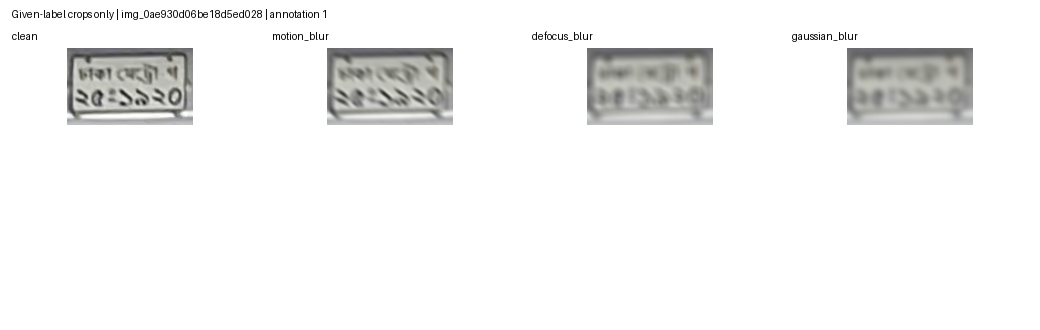

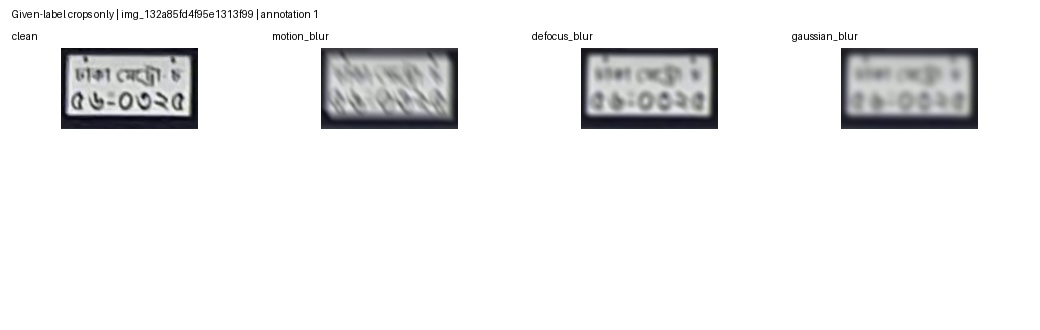

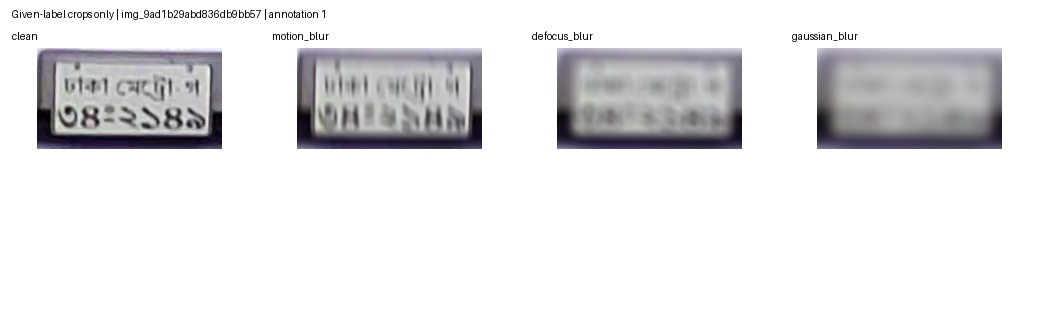

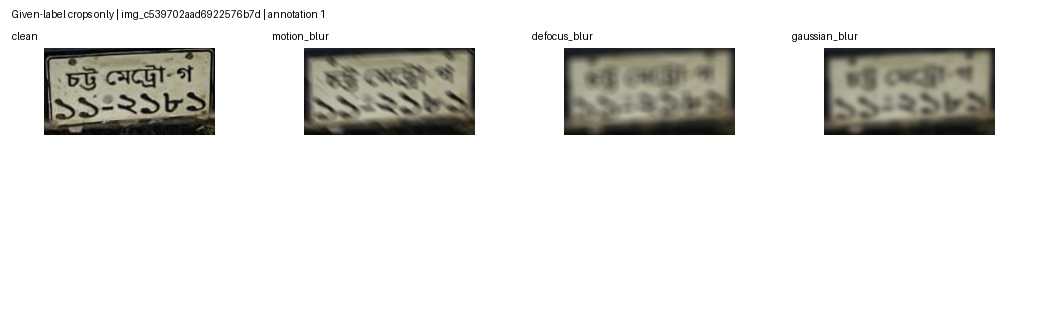

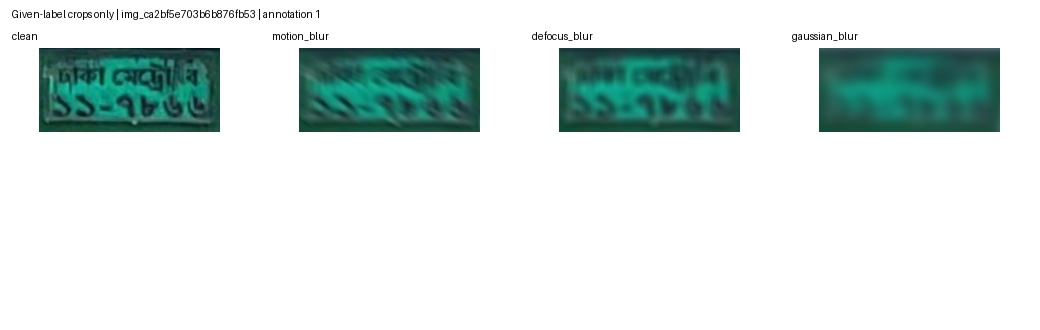

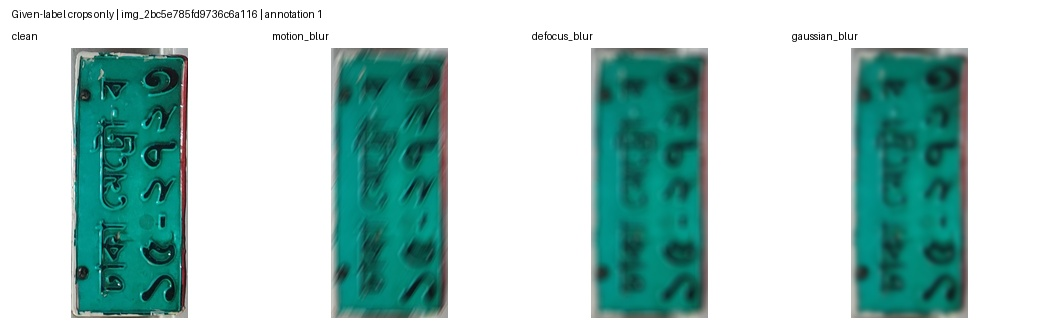

In [11]:
GENERATION = prepare_artifacts(RECORDS, CLASS_NAMES, PLATE_CLASSES, AUDIT, CFG)
YAML_PATHS = make_dataset_yamls(CLASS_NAMES, CFG)
PREVIEWS = create_crop_previews(CFG, max_plates=6)
print(json.dumps(GENERATION, indent=2))
print("Master CSV:", CFG.output / "easyocr_finetuning_training" / "labels_master.csv")
from IPython.display import display
for preview in PREVIEWS:
    display(Image.open(preview))

In [12]:
from pathlib import Path

root = CFG.output

folders = [
    "clean_plates",
    "motion_blurr_plate",
    "defocus_blurr_plate",
    "gaussian_blurr_plate",
]

print("FULL OUTPUT CHECK")
print("=" * 60)

for folder in folders:
    print(f"\n{folder}")
    total = 0

    for split in ("train", "val", "test"):
        path = root / folder / split
        count = len(list(path.glob("*.png")))
        total += count
        print(f"  {split}: {count}")

    print(f"  TOTAL: {total}")

csv_path = (
    root
    / "easyocr_finetuning_training"
    / "labels_master.csv"
)

print("\nlabels_master.csv exists:", csv_path.is_file())

if csv_path.is_file():
    master = pd.read_csv(
        csv_path,
        keep_default_na=False
    )
    print("CSV rows:", len(master))
    print(master["split"].value_counts())

FULL OUTPUT CHECK

clean_plates
  train: 1464
  val: 845
  test: 412
  TOTAL: 2721

motion_blurr_plate
  train: 1464
  val: 845
  test: 412
  TOTAL: 2721

defocus_blurr_plate
  train: 1464
  val: 845
  test: 412
  TOTAL: 2721

gaussian_blurr_plate
  train: 1464
  val: 845
  test: 412
  TOTAL: 2721

labels_master.csv exists: True
CSV rows: 10884
split
train    5856
val      3380
test     1648
Name: count, dtype: int64


## Cell 11 - Review gate, then train YOLOv8m-OBB
**Pause before this cell.** Inspect the crop previews and the reports from Cell 09, especially excluded_source_images.csv and cross_split_exclusions.csv. Check additional
source images/crops yourself, especially heavily rotated, loose, tiny, multi-plate, or unusual examples.
Resolve genuine duplicate/identity leakage in the source splits or authoritative grouping metadata.

Set the first line below to `True` only after review. This deliberate review gate is not a software bug.
Reset it to `False` when changing to a new dataset or full run. Do not use test scores to tune training.

For the full experiment, change `RUN_MODE="full"` in Cell 01, reset this review flag, and run Cells 01-10
again. Inspect the full-run outputs, then approve and run Cells 11-13. Helpers may stay folded but must
have run in the current kernel. The same local source dataset is reused; smoke results are not mixed with full results.


In [13]:
REVIEW_APPROVED = True  # Change to True after inspecting source/split reports and GT crop quality.
if not REVIEW_APPROVED:
    raise RuntimeError(
        "Review gate: inspect the Cell 09 reports and Cell 10 GT crops, "
        "then set REVIEW_APPROVED=True and rerun this cell."
    )
write_json(CFG.output / "quality_checks" / "review_approval.json", {
    "approved_utc": utc_now(), "run_mode": CFG.run_mode,
    "source_fingerprint": AUDIT["source_fingerprint"],
    "generation_fingerprint": GENERATION["generation_fingerprint"],
    "near_duplicate_candidates_reviewed": AUDIT["near_duplicate_candidates"],
    "note": "User acknowledgement; this is not automated proof of physical-identity disjointness."
})
BEST_WEIGHTS = train_detector(CFG, YAML_PATHS, ENVIRONMENT)
print("Best model:", BEST_WEIGHTS)

New https://pypi.org/project/ultralytics/8.4.153 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.228  Python-3.12.3 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\Thesis-Tahmid\LPD4K_OBB_project\LPD4K_OBB_work\experiments\lpd4k_v8m_obb_05_defocus_gaussian_stronger\full\dataset_configs\training.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.15, hsv_v=0.15, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0

KeyboardInterrupt: 

## Cell 12 - Validation and held-out testing, four conditions each
The saved **best** checkpoint is used for all eight comparisons. Ground truth and predictions are
matched for metrics only. No recognition crop is regenerated from predictions. Do not retune thresholds
or hyperparameters after inspecting test scores; run a new predeclared experiment when comparing methods.

In [12]:
METRICS = evaluate_detector(BEST_WEIGHTS, RECORDS, YAML_PATHS, CFG, ENVIRONMENT)
percentage_view = METRICS[[
    "run_mode", "split", "variant", "mAP50_ultralytics", "mAP50_95_ultralytics",
    "precision_fixed", "recall_fixed", "f1_fixed", "tp", "fp", "fn"
]].copy()
for column in ["mAP50_ultralytics", "mAP50_95_ultralytics", "precision_fixed", "recall_fixed", "f1_fixed"]:
    percentage_view[column + "_percent"] = 100 * percentage_view.pop(column)
display(percentage_view.round(3))
print("Raw 0-1 metrics CSV:", CFG.output / "evaluation" / "metrics_summary.csv")
if CFG.run_mode == "smoke":
    print("SMOKE CHECK ONLY: do not report these numbers as full-dataset performance.")

Ultralytics 8.3.228  Python-3.12.3 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
YOLOv8m-obb summary (fused): 101 layers, 26,400,646 parameters, 0 gradients, 80.8 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1741.81154.1 MB/s, size: 3847.6 KB)
val: Scanning D:\Thesis-Tahmid\LPD4K_OBB_project\LPD4K_OBB_work\experiments\lpd4k_v8m_obb_04_stronger_blur\smoke\detector_data\clean\val\labels.cache... 4 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 4.8it/s 0.4s
                   all          4          4    0.00304       0.75     0.0165    0.00277
Speed: 0.7ms preprocess, 27.4ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to D:\Thesis-Tahmid\LPD4K_OBB_project\LPD4K_OBB_work\experiments\lpd4k_v8m_obb_04_stronger_blur\smoke\evaluation\ultralytics\val__clean


Fixed-threshold val/clean:   0%|          | 0/2 [00:00<?, ?it/s]

Ultralytics 8.3.228  Python-3.12.3 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 586.8621.7 MB/s, size: 3468.1 KB)
val: Scanning D:\Thesis-Tahmid\LPD4K_OBB_project\LPD4K_OBB_work\experiments\lpd4k_v8m_obb_04_stronger_blur\smoke\detector_data\motion_blur\val\labels... 4 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4 281.1it/s 0.0s
val: New cache created: D:\Thesis-Tahmid\LPD4K_OBB_project\LPD4K_OBB_work\experiments\lpd4k_v8m_obb_04_stronger_blur\smoke\detector_data\motion_blur\val\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 5.1it/s 0.4s
                   all          4          4    0.00326       0.75    0.00649    0.00193
Speed: 0.7ms preprocess, 26.5ms inference, 0.0ms loss, 5.2ms postprocess per image
Results saved to D:\Thesis-Tahmid\LPD4K_OBB_project\LPD4K_OBB_work\experiments\lpd4k_v8m_obb_04_stronger_blur\smoke\evaluation\ultra

Fixed-threshold val/motion_blur:   0%|          | 0/2 [00:00<?, ?it/s]

Ultralytics 8.3.228  Python-3.12.3 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 518.1616.1 MB/s, size: 2763.4 KB)
val: Scanning D:\Thesis-Tahmid\LPD4K_OBB_project\LPD4K_OBB_work\experiments\lpd4k_v8m_obb_04_stronger_blur\smoke\detector_data\defocus_blur\val\labels... 4 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4 318.1it/s 0.0s
val: New cache created: D:\Thesis-Tahmid\LPD4K_OBB_project\LPD4K_OBB_work\experiments\lpd4k_v8m_obb_04_stronger_blur\smoke\detector_data\defocus_blur\val\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 5.2it/s 0.4s
                   all          4          4    0.00229        0.5    0.00523    0.00206
Speed: 0.9ms preprocess, 21.6ms inference, 0.0ms loss, 4.7ms postprocess per image
Results saved to D:\Thesis-Tahmid\LPD4K_OBB_project\LPD4K_OBB_work\experiments\lpd4k_v8m_obb_04_stronger_blur\smoke\evaluation\ult

...

Fixed-threshold test/defocus_blur:   0%|          | 0/2 [00:00<?, ?it/s]

Ultralytics 8.3.228  Python-3.12.3 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 601.4449.3 MB/s, size: 2999.3 KB)
val: Scanning D:\Thesis-Tahmid\LPD4K_OBB_project\LPD4K_OBB_work\experiments\lpd4k_v8m_obb_04_stronger_blur\smoke\detector_data\gaussian_blur\test\labels... 4 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4 331.7it/s 0.0s
val: New cache created: D:\Thesis-Tahmid\LPD4K_OBB_project\LPD4K_OBB_work\experiments\lpd4k_v8m_obb_04_stronger_blur\smoke\detector_data\gaussian_blur\test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 5.4it/s 0.4s0.4s
                   all          4          4    0.00227        0.5    0.00259   0.000518
Speed: 0.9ms preprocess, 22.8ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to D:\Thesis-Tahmid\LPD4K_OBB_project\LPD4K_OBB_work\experiments\lpd4k_v8m_obb_04_stronger_blur\smoke\evalua

Fixed-threshold test/gaussian_blur:   0%|          | 0/2 [00:00<?, ?it/s]

,run_mode,split,variant,tp,fp,fn,mAP50_ultralytics_percent,mAP50_95_ultralytics_percent,precision_fixed_percent,recall_fixed_percent,f1_fixed_percent
0,smoke,val,clean,0,0,4,1.654,0.277,0.0,0.0,0.0
1,smoke,val,motion_blur,0,0,4,0.649,0.193,0.0,0.0,0.0
2,smoke,val,defocus_blur,0,0,4,0.523,0.206,0.0,0.0,0.0
3,smoke,val,gaussian_blur,0,0,4,1.631,0.592,0.0,0.0,0.0
4,smoke,test,clean,0,0,4,0.202,0.091,0.0,0.0,0.0
5,smoke,test,motion_blur,0,0,4,0.290,0.067,0.0,0.0,0.0
6,smoke,test,defocus_blur,0,0,4,0.241,0.055,0.0,0.0,0.0
7,smoke,test,gaussian_blur,0,0,4,0.259,0.052,0.0,0.0,0.0


Raw 0-1 metrics CSV: D:\Thesis-Tahmid\LPD4K_OBB_project\LPD4K_OBB_work\experiments\lpd4k_v8m_obb_04_stronger_blur\smoke\evaluation\metrics_summary.csv
SMOKE CHECK ONLY: do not report these numbers as full-dataset performance.


## Cell 13 - Verify outputs and locate the recognition CSV
Fresh `words` values are all blank. Open the CSV in a Unicode-safe editor, keep the four headers and
all filenames/splits/IDs unchanged, and fill only `words`. The same visible plate text normally applies
to its four variants; do not invent text that cannot be established from the source. Close the CSV before
rerunning generation on Windows. A rerun preserves exact text and makes a timestamped backup.

These are whole-plate crops. For example, a line region could be transcribed as `ঢাকা মেট্রো`
or `গ ১২-৩৪৫৬`, but a full-plate crop needs the text of the **entire visible crop**.
Do not fill only one line while leaving other visible text out. EasyOCR's later training format and
Bengali vocabulary setup are a separate task after transcription/region preparation.

Back up the experiment folder to durable storage before a remote machine/temporary disk is deleted.
Nothing is automatically uploaded to your Drive. Downloading only small checkpoints/reports later is
optional; downloading the dataset to the laptop is not required in the remote-kernel workflow.


In [13]:
FINAL_SUMMARY = verify_deliverables(CFG)
print("\nImportant outputs:")
print("  Weights:", CFG.output / "detector_runs" / "yolov8m_obb" / "weights")
print("  Detector metrics:", CFG.output / "evaluation" / "metrics_summary.csv")
print("  Manual Bengali labels:", CFG.output / "easyocr_finetuning_training" / "labels_master.csv")
print("  Source-to-crop traceability:", CFG.output / "reports" / "crop_manifest.csv")
for folder in CROP_FOLDERS.values():
    print("  Crop folder:", CFG.output / folder)

{
  "run_mode": "smoke",
  "output_root": "D:\\Thesis-Tahmid\\LPD4K_OBB_project\\LPD4K_OBB_work\\experiments\\lpd4k_v8m_obb_04_stronger_blur\\smoke",
  "recognition_images": 48,
  "blank_words": 48,
  "crop_counts": {
    "clean_plates": 12,
    "motion_blurr_plate": 12,
    "defocus_blurr_plate": 12,
    "gaussian_blurr_plate": 12
  },
  "source_annotations": 12,
  "labels_master_csv": "D:\\Thesis-Tahmid\\LPD4K_OBB_project\\LPD4K_OBB_work\\experiments\\lpd4k_v8m_obb_04_stronger_blur\\smoke\\easyocr_finetuning_training\\labels_master.csv",
  "detector_training_complete": true,
  "detector_evaluation_complete": true,
  "physical_identity_caveat": "Cross-photo vehicle/plate/video identity still requires user review."
}

Important outputs:
  Weights: D:\Thesis-Tahmid\LPD4K_OBB_project\LPD4K_OBB_work\experiments\lpd4k_v8m_obb_04_stronger_blur\smoke\detector_runs\yolov8m_obb\weights
  Detector metrics: D:\Thesis-Tahmid\LPD4K_OBB_project\LPD4K_OBB_work\experiments\lpd4k_v8m_obb_04_stronger_b

## Restarting safely
After a kernel restart, run Cells 01-10 again to reconstruct variables and re-audit the same local dataset.
Completed, unchanged training is reused automatically. For an **interrupted** run with a real `last.pt`,
set `TRAIN_ACTION="resume"` in Cell 01 before repeating Cells 01-11. Changing the target epochs, dataset,
seed, image size, or other experiment settings requires a new `EXPERIMENT` name rather than mixing runs.
A completed run is not resumed to extend its epoch count.

## Technical references and validation scope
- [YOLO OBB label specification](https://docs.ultralytics.com/datasets/obb/)
- [YOLOv8 model variants](https://docs.ultralytics.com/models/yolov8/)
- [Training](https://docs.ultralytics.com/modes/train/) and [validation](https://docs.ultralytics.com/modes/val/)
- [OBB validator](https://docs.ultralytics.com/reference/models/yolo/obb/val/)
- [OpenCV geometric transforms](https://docs.opencv.org/4.x/da/d54/group__imgproc__transform.html)
- [VS Code Jupyter](https://code.visualstudio.com/docs/datascience/jupyter-notebooks)
- [PyTorch installer](https://pytorch.org/get-started/locally/)
- [EasyOCR custom recognition models](https://github.com/JaidedAI/EasyOCR/blob/master/custom_model.md)

This local-data notebook is adapted from the original tested workflow. Data/crop/CSV logic remains the same;
only the dataset acquisition layer has been replaced by a direct local-folder check. No actual dataset accuracy
is claimed before you run training and evaluation. Start with smoke mode and resolve real errors rather than
disabling the safeguards.